<a href="https://colab.research.google.com/github/diemacedo12/lis4693-lis5693/blob/main/lab-7/lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing packages

In [4]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

 Loading BBC news dataset

In [5]:
import requests
import io

url = "https://raw.githubusercontent.com/diemacedo12/lis4693-lis5693/refs/heads/main/lab-4/bbc-news-data.csv"
response = requests.get(url)
response.raise_for_status()
text = response.text
df = pd.read_csv(io.StringIO(text), sep='\t')

print(df.head())

   category filename                              title  \
0  business  001.txt  Ad sales boost Time Warner profit   
1  business  002.txt   Dollar gains on Greenspan speech   
2  business  003.txt  Yukos unit buyer faces loan claim   
3  business  004.txt  High fuel prices hit BA's profits   
4  business  005.txt  Pernod takeover talk lifts Domecq   

                                             content  
0   Quarterly profits at US media giant TimeWarne...  
1   The dollar has hit its highest level against ...  
2   The owners of embattled Russian oil giant Yuk...  
3   British Airways has blamed high fuel prices f...  
4   Shares in UK drinks and food firm Allied Dome...  


Creating a subset

In [6]:
df_subset = df[['filename', 'content']].copy()

Cleaning text and removing non-alphabet characters and converting to lowercase

In [7]:
df_subset['ObjectId'] = df_subset['filename'].str.replace('.txt', '').astype(int)

df_subset = df_subset.rename(columns={'content': 'Description'})

df_subset['Description'] = df_subset['Description'].str.replace("[^a-zA-Z#]", " ")

# Convert to Lower-case
df_subset['Description'] = df_subset['Description'].str.casefold()

print(df_subset.head(10))

  filename                                        Description  ObjectId
0  001.txt   quarterly profits at us media giant timewarne...         1
1  002.txt   the dollar has hit its highest level against ...         2
2  003.txt   the owners of embattled russian oil giant yuk...         3
3  004.txt   british airways has blamed high fuel prices f...         4
4  005.txt   shares in uk drinks and food firm allied dome...         5
5  006.txt   japan's economy teetered on the brink of a te...         6
6  007.txt   the us created fewer jobs than expected in ja...         7
7  008.txt   india, which attends the g7 meeting of seven ...         8
8  009.txt   ethiopia produced 14.27 million tonnes of cro...         9
9  010.txt   a us government claim accusing the country's ...        10


In [8]:
df1 = pd.DataFrame()
df1['ObjectId'] = ['9999999999999']
df1['sentiment_type'] = 'NA99NA'
df1['sentiment_score'] = 0

Using VADER to generate compound sentiment polarity scores



In [9]:
print('Processing sentiment analysis...')
sid = SentimentIntensityAnalyzer()

all_scores_list = [] # Use a list to collect results

for index, row in df_subset.iterrows():
    scores = sid.polarity_scores(row['Description']) # Access by column name for clarity and robustness
    for key, value in scores.items():
        all_scores_list.append({
            'ObjectId': row['ObjectId'], # Access by column name
            'sentiment_type': key,
            'sentiment_score': value
        })

# Create a DataFrame from the list of dictionaries after the loop
t_df_all_types = pd.DataFrame(all_scores_list)

# Filter for compound sentiment and remove duplicates
t_df_cleaned = t_df_all_types[t_df_all_types.sentiment_type == 'compound'].drop_duplicates()

print(t_df_cleaned.head(10))

Processing sentiment analysis...
    ObjectId sentiment_type  sentiment_score
3          1       compound           0.9950
7          2       compound           0.9347
11         3       compound          -0.8860
15         4       compound           0.9790
19         5       compound           0.6652
23         6       compound           0.6204
27         7       compound           0.9547
31         8       compound          -0.6795
35         9       compound          -0.2023
39        10       compound           0.2263


Merging sentiment scores back to the original dataset







In [10]:
df['ObjectId'] = df['filename'].str.replace('.txt', '', regex=False).astype(int)
df_output = pd.merge(df, t_df_cleaned, on='ObjectId', how='inner')
print(df_output.head(10))

   category filename                              title  \
0  business  001.txt  Ad sales boost Time Warner profit   
1  business  001.txt  Ad sales boost Time Warner profit   
2  business  001.txt  Ad sales boost Time Warner profit   
3  business  001.txt  Ad sales boost Time Warner profit   
4  business  001.txt  Ad sales boost Time Warner profit   
5  business  002.txt   Dollar gains on Greenspan speech   
6  business  002.txt   Dollar gains on Greenspan speech   
7  business  002.txt   Dollar gains on Greenspan speech   
8  business  002.txt   Dollar gains on Greenspan speech   
9  business  002.txt   Dollar gains on Greenspan speech   

                                             content  ObjectId sentiment_type  \
0   Quarterly profits at US media giant TimeWarne...         1       compound   
1   Quarterly profits at US media giant TimeWarne...         1       compound   
2   Quarterly profits at US media giant TimeWarne...         1       compound   
3   Quarterly profits at U

Generating summary statistics of sentiment scores



In [11]:
df_output[["sentiment_score"]].describe()

,sentiment_score
count,10387.000000
mean,0.402121
std,0.790898
min,-0.999900
25%,-0.421500
50%,0.921100
75%,0.983200
max,1.000000


What is the 'text' field for your dataset?

The 'text' field for my dataset is content.

Which common column did you choose to merge your original dataset with the sentiment scores?

I used the ObjectId column.

Briefly explain your sentiment polarity results using the describe method.

The mean sentiment score is negative. Most articles have a negative tone because they talk about problems and difficult, somewhat touchy topics.

Visualizing sentiment scores using a histogram


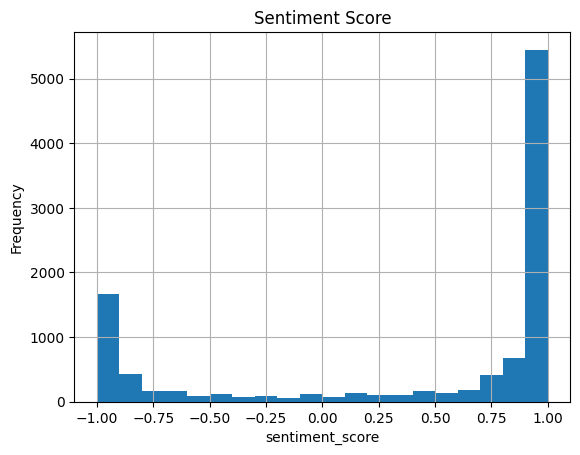

In [15]:
df_output['sentiment_score'].hist(bins=20)
plt.title('Sentiment Score')
plt.xlabel('sentiment_score')
plt.ylabel('Frequency')
plt.show()

Visualizing sentiment scores using a bar plot


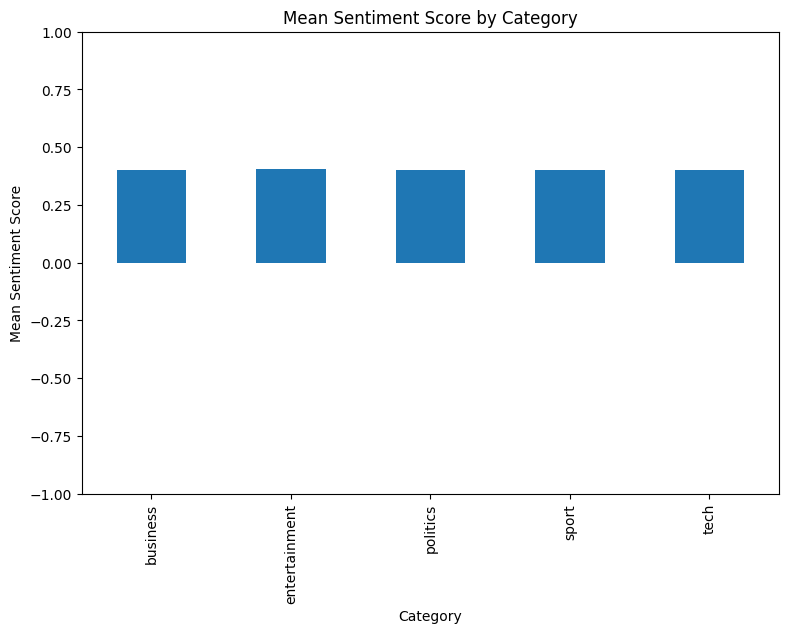

In [17]:
dfg = df_output.groupby(['category'])['sentiment_score'].mean()
dfg.plot(kind='bar', title='Mean Sentiment Score by Category', ylabel='Mean Sentiment Score',
         xlabel='Category', figsize=(9, 6))

plt.ylim(-1, 1)
plt.show()

The histogram shows most articles have negative sentiment scores.  

The bar plot shows the average sentiment score for each category.

Reflection

What went well? What did not go well, or what challenges did you encounter?

Loading the data and running the sentiment analysis went well. The main challenge was that the sentiment scores across categories were very close together, so the bar plot did not look right at first.The vizualization was the hardest part. Rest of the assignment was a breeze.


In what ways could sentiment analysis be integrated into your current or future professional or research work?

Sentiment analysis can help check the tone of news articles or track how positive or negative the coverage is on different topics.